<a href="https://colab.research.google.com/github/cl2832/CHEME-5660-CourseRepository-Fall-2025/blob/main/GTG_performance/CHP_IAC_CausalRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/cl2832/insight-chp/blob/main/GTG_performance/CHP_IAC_CausalRegression_Clean.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CHP Causal Regression — IAC Uplift Analysis (Clean)
## Cornell Combined Heat and Power Plant
### Estimating cooled-vs-uncooled incremental GTG power

**Pipeline**: Load → CONFIG → Prepare → Fit (full data) → Overlap filter → Uplift (strong only) → Bootstrap CI → Diagnostics (optional)


---
## 1. Setup


In [2]:
# ============================================================================
# ALL IMPORTS (single cell, no duplicates)
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from pathlib import Path
import warnings, os, sys, time
warnings.filterwarnings('ignore')

import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix, bs
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.grid': True, 'grid.alpha': 0.3})
print('All imports done')


All imports done


---
## 2. Load Data


In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')


Mounted at /content/drive
Google Drive mounted


In [4]:
from google.colab import userdata
!rm -rf /content/insight-chp
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/cl2832/insight-chp.git /content/insight-chp
sys.path.insert(0, '/content/insight-chp/GTG_performance')
from src.chp_preprocessing import load_and_preprocess
print('Import successful')


Cloning into '/content/insight-chp'...
remote: Enumerating objects: 320, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (115/115), done.
Receiving objects: 100% (320/320), 10.90 MiB | 12.31 MiB/s, done.
remote: Total 320 (delta 73), reused 20 (delta 6), pack-reused 198 (from 1)
Resolving deltas: 100% (178/178), done.
Import successful


In [5]:
results = load_and_preprocess(
    data_path='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/'
              'merged_chp_data_jul2025_canonical.xlsx',
    cache_dir='/content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data',
    power_threshold_mw=11.0,
    filtering_mode='manual',
    show_plots=False,
    cooling_mode='binary',
)

df      = results['df']
df_ct1  = results['df_ct1']
df_ct2  = results['df_ct2']
df_both = results['df_both']
print(f'df_ct1: {len(df_ct1):,}  |  df_ct2: {len(df_ct2):,}')


📦 Loading from CACHE: /content/drive/MyDrive/M.Eng._Project/Data/chp_raw_data/merged_chp_data_jul2025_canonical.pkl
   ✅ 44,640 rows × 89 columns

CALCULATING PERFORMANCE METRICS

📊 CT1 Metrics:
   ✓ ct1_power_mw
   ✓ ct1_heat_input_mmbtu_h
   ✓ ct1_efficiency_pct (avg: 25.65%, 44,176 valid)

📊 CT2 Metrics:
   ✓ ct2_power_mw
   ✓ ct2_heat_input_mmbtu_h
   ✓ ct2_efficiency_pct (avg: 31.02%, 44,623 valid)

❄️  IAC Status:
   ✓ cooling_on  (BINARY mode, threshold: 50.0 GPM)
     • Flow range: -2.9 – 1172.7 GPM
     • ON:  20,476 records
     • OFF: 24,164 records

OPERATIONAL STATUS SUMMARY
Threshold: 11.0 MW

CT1:  Operating 35,820 (80.2%)  |  Offline 8,820 (19.8%)
CT2:  Operating 44,612 (99.9%)  |  Offline 28 (0.1%)

Combined:
  Both ON:   35,804  (80.2%)
  CT1 only:  16  (0.0%)
  CT2 only:  8,808  (19.7%)
  Both OFF:  12  (0.0%)

SMART FILTERING (INDEPENDENT CT1 & CT2)

🎯 MANUAL MODE: fixed thresholds
   CT1: > 11.0 MW
   CT2: > 11.0 MW

📊 Filtering Results:
  Original:      44,640 rec

---
## 3. CONFIG
Single source of truth for all parameters.


In [6]:
# ============================================================================
# NESTED CONFIG
# ============================================================================
CONFIG = {
    'data': {
        'train_temp_range_F':  (55, 110),   # model training (full range)
        'report_temp_range_F': (55, 110),   # uplift reporting (can narrow)
    },
    'treatment': {
        'method':           'full_vs_off',  # 'simple', 'deadband', 'full_vs_off'
        'switch_window_min': 10,            # decontamination window
    },
    'model': {
        'spec': 'A',                        # 'A' or 'B'
    },
    'overlap': {
        'enabled':          True,
        'strategy':         'strong_grid',  # temp_bin x hour
        'temp_bin_width_F': 2.5,
        'strong_min':       50,             # min(n_on, n_off) for strong
        'weak_min':         20,             # min(n_on, n_off) for weak
        'min_total':        50,             # n_total threshold
        'on_rate_lo':       0.10,
        'on_rate_hi':       0.90,
    },
    'bootstrap': {
        'n_iterations':  100,
        'ci_level':      0.95,
    },
    'diagnostics': {
        'enabled':              True,
        'binned_diff_width_F':  2,
        'test_days_frac':       0.2,
        'jackknife_enabled':    True,
        'jackknife_max_days':   40,
    },
    'seed':       42,
    'output_dir': './outputs',
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
np.random.seed(CONFIG['seed'])

# Pretty-print
def _pp(d, indent=0):
    for k, v in d.items():
        if isinstance(v, dict):
            print(' ' * indent + f'{k}:')
            _pp(v, indent + 4)
        else:
            print(' ' * indent + f'{k:25s} = {v}')

print('CONFIG:'); _pp(CONFIG)


CONFIG:
data:
    train_temp_range_F        = (55, 110)
    report_temp_range_F       = (55, 110)
treatment:
    method                    = full_vs_off
    switch_window_min         = 10
model:
    spec                      = A
overlap:
    enabled                   = True
    strategy                  = strong_grid
    temp_bin_width_F          = 2.5
    strong_min                = 50
    weak_min                  = 20
    min_total                 = 50
    on_rate_lo                = 0.1
    on_rate_hi                = 0.9
bootstrap:
    n_iterations              = 100
    ci_level                  = 0.95
diagnostics:
    enabled                   = True
    binned_diff_width_F       = 2
    test_days_frac            = 0.2
    jackknife_enabled         = True
    jackknife_max_days        = 40
seed                      = 42
output_dir                = ./outputs


---
## 4. Core Helper Functions
All functions defined before first use.


### 4a. Data Preparation (treatment + decontaminate + filter)


In [7]:
# ============================================================================
# prepare_df: treatment assignment + decontamination + temp filter + time cols
# ============================================================================

def assign_treatment(df, method='full_vs_off'):
    """Assign treatment D based on IAC chilled-water flow."""
    flow = df['iac_cw_flow_gpm']
    if method == 'simple':
        return (flow > 50).astype(float)
    elif method == 'deadband':
        D = pd.Series(np.nan, index=df.index)
        D[flow >= 60] = 1.0
        D[flow <= 40] = 0.0
        return D
    elif method == 'full_vs_off':
        D = pd.Series(np.nan, index=df.index)
        D[flow >= 800] = 1.0
        D[flow <= 20]  = 0.0
        return D
    else:
        raise ValueError(f'Unknown method: {method}')


def decontaminate_switches(df, d_col='D', ts_col='TimeStamp', window_min=10):
    """Drop rows within +/- window_min of any treatment switch."""
    df = df.sort_values(ts_col).copy()
    d = df[d_col]
    change_idx = d.ne(d.shift()).fillna(False)
    change_times = df.loc[change_idx, ts_col]
    window = pd.Timedelta(minutes=window_min)
    mask_keep = pd.Series(True, index=df.index)
    for ct in change_times:
        mask_keep &= ~df[ts_col].between(ct - window, ct + window)
    return df[mask_keep]


def prepare_df(df_raw, ct_label, temp_range, treatment_cfg):
    """Full pipeline: treatment -> decontaminate -> temp filter -> time cols.
    Returns cleaned DataFrame ready for regression."""
    df = df_raw.copy()

    # 1. Treatment
    df['D'] = assign_treatment(df, treatment_cfg['method'])
    n0 = len(df)
    df = df.dropna(subset=['D'])
    print(f"  {ct_label}: treatment '{treatment_cfg['method']}' -> "
          f'dropped {n0 - len(df):,} partial rows')

    # 2. Decontaminate
    n1 = len(df)
    df = decontaminate_switches(df, window_min=treatment_cfg['switch_window_min'])
    print(f"  {ct_label}: decontamination (+/-{treatment_cfg['switch_window_min']}min) "
          f'-> dropped {n1 - len(df):,} rows')

    # 3. Temp filter
    lo, hi = temp_range
    df = df[df['ambient_air_temp_f'].between(lo, hi)].copy()
    print(f'  {ct_label}: temp [{lo}-{hi}F] -> {len(df):,} rows')

    # 4. Time columns
    df['hour'] = df['TimeStamp'].dt.hour
    df['day']  = df['TimeStamp'].dt.date
    return df

print('prepare_df defined')


prepare_df defined


### 4b. Regression (build_formula + fit_model)


In [8]:
# ============================================================================
# build_formula / fit_model
# ============================================================================

def build_formula(ct_prefix, spec='A'):
    """Return (y_col, formula_string) for OLS."""
    y = f'{ct_prefix}_power_mw'
    rhs = [
        'D',
        'bs(ambient_air_temp_f, df=5, degree=3)',
        'D : bs(ambient_air_temp_f, df=5, degree=3)',
        'ambient_rh_pct',
        f'{ct_prefix}_gas_supply_pressure_psi',
        f'{ct_prefix}_inlet_air_supply_pressure_psig',
        'C(hour)',
    ]
    if spec == 'B':
        rhs += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    return y, f'{y} ~ ' + ' + '.join(rhs)


def fit_model(df, ct_prefix, ct_label, spec='A'):
    """Fit OLS with cluster-robust SE (day clusters). Returns model or None."""
    y_col, formula = build_formula(ct_prefix, spec)

    needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
              f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig', 'hour', 'day']
    if spec == 'B':
        needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']

    missing = [c for c in needed if c not in df.columns]
    if missing:
        print(f'  {ct_label}: Spec {spec} skipped -- missing {missing}')
        return None

    reg_cols = [c for c in needed if c != 'day']
    df_reg = df.dropna(subset=reg_cols).copy()
    if len(df_reg) < 100:
        print(f'  {ct_label}: too few rows ({len(df_reg)}), skipping')
        return None

    groups = df_reg['day'].astype(str)
    try:
        model = smf.ols(formula, data=df_reg).fit(
            cov_type='cluster', cov_kwds={'groups': groups})
    except Exception as e:
        print(f'  {ct_label}: fit failed -- {e}')
        return None

    model._df_reg    = df_reg
    model._ct_prefix = ct_prefix
    model._spec      = spec

    print(f'  {ct_label} Spec {spec}: N={len(df_reg):,}  '
          f'R2={model.rsquared:.4f}  clusters={groups.nunique()}')
    if 'D' in model.params.index:
        print(f'    D coef={model.params["D"]:+.4f}  p={model.pvalues["D"]:.4f}')
    return model

print('Regression helpers defined')


Regression helpers defined


### 4c. Counterfactual Uplift


In [9]:
# ============================================================================
# counterfactual_uplift / point_uplift
# ============================================================================

def counterfactual_uplift(model, df=None):
    """Row-level uplift = predict(D=1) - predict(D=0).
    If df is None, uses model._df_reg."""
    if df is None:
        df = model._df_reg
    df_on  = df.copy(); df_on['D']  = 1.0
    df_off = df.copy(); df_off['D'] = 0.0
    return model.predict(df_on) - model.predict(df_off)


def point_uplift(model, df_ref, temp, hour=15):
    """Uplift at a single (temp, hour) point, using medians for other covariates."""
    ct = model._ct_prefix
    t_lo = df_ref['ambient_air_temp_f'].min()
    t_hi = df_ref['ambient_air_temp_f'].max()
    tc = np.clip(temp, t_lo, t_hi)

    row = pd.DataFrame({
        'D':                [1.0, 0.0],
        'ambient_air_temp_f': [tc, tc],
        'ambient_rh_pct':   [df_ref['ambient_rh_pct'].median()] * 2,
        f'{ct}_gas_supply_pressure_psi':
            [df_ref[f'{ct}_gas_supply_pressure_psi'].median()] * 2,
        f'{ct}_inlet_air_supply_pressure_psig':
            [df_ref[f'{ct}_inlet_air_supply_pressure_psig'].median()] * 2,
        'hour': [hour, hour],
    })
    for extra in [f'{ct}_pcd', f'{ct}_t7_avg_temp']:
        if extra in df_ref.columns and extra in str(model.model.formula):
            row[extra] = df_ref[extra].median()
    yhat = model.predict(row)
    return float(yhat.iloc[0] - yhat.iloc[1])

print('Uplift helpers defined')


Uplift helpers defined


### 4d. Overlap Filter (strong-grid, fast vectorized)


In [10]:
# ============================================================================
# apply_overlap_filter: build grid + return filtered df + metadata
# ============================================================================

def _build_overlap_grid(df, ovl_cfg):
    """Compute (temp_bin, hour) grid with strong/weak/none classification."""
    bw = ovl_cfg['temp_bin_width_F']
    lo = np.floor(df['ambient_air_temp_f'].min() / bw) * bw
    hi = np.ceil(df['ambient_air_temp_f'].max() / bw) * bw + bw
    bins = np.arange(lo, hi, bw)
    tmp = df.copy()
    tmp['temp_bin'] = pd.cut(tmp['ambient_air_temp_f'], bins=bins)

    grid = tmp.groupby(['temp_bin', 'hour'])['D'].agg(
        n_on  = lambda x: (x == 1).sum(),
        n_off = lambda x: (x == 0).sum(),
        n_total = 'count',
    ).reset_index()
    grid['on_rate']   = grid['n_on'] / grid['n_total'].clip(lower=1)
    grid['min_count'] = grid[['n_on', 'n_off']].min(axis=1)

    def classify(r):
        if r['n_total'] < ovl_cfg['min_total'] or r['min_count'] < ovl_cfg['weak_min']:
            return 'none'
        if (r['min_count'] >= ovl_cfg['strong_min']
            and ovl_cfg['on_rate_lo'] <= r['on_rate'] <= ovl_cfg['on_rate_hi']):
            return 'strong'
        return 'weak'

    grid['overlap_class'] = grid.apply(classify, axis=1)
    grid['class_num'] = grid['overlap_class'].map(
        {'none': 0, 'weak': 1, 'strong': 2})
    return grid, bins


def _build_strong_mask(df, grid, bins):
    """Vectorized row-level mask via merge (fast)."""
    tmp = df.copy()
    tmp['temp_bin'] = pd.cut(tmp['ambient_air_temp_f'], bins=bins)
    tmp['tb_str']   = tmp['temp_bin'].astype(str)

    strong = grid[grid['overlap_class'] == 'strong'][['temp_bin', 'hour']].copy()
    strong['tb_str'] = strong['temp_bin'].astype(str)
    strong['_s'] = True

    merged = tmp[['tb_str', 'hour']].merge(
        strong[['tb_str', 'hour', '_s']], on=['tb_str', 'hour'], how='left')
    mask = merged['_s'].fillna(False).values
    return pd.Series(mask, index=df.index), tmp['temp_bin']


def _overlap_summary(grid):
    """Summary: per temp_bin count of strong/weak/none hours."""
    ct = pd.crosstab(grid['temp_bin'], grid['overlap_class'])
    for c in ['none', 'weak', 'strong']:
        if c not in ct.columns:
            ct[c] = 0
    ct = ct[['none', 'weak', 'strong']]
    ct['total_hours'] = ct.sum(axis=1)
    ct['strong_pct']  = (ct['strong'] / ct['total_hours'] * 100).round(1)
    return ct.reset_index()


def apply_overlap_filter(df, ovl_cfg):
    """Main entry point: build grid, apply strong mask, return (df_strong, meta)."""
    grid, bins = _build_overlap_grid(df, ovl_cfg)
    mask, temp_bins = _build_strong_mask(df, grid, bins)
    summary = _overlap_summary(grid)

    df_strong = df[mask.values].copy()
    df_strong['temp_bin'] = temp_bins[mask.values].values

    vc = grid['overlap_class'].value_counts()
    meta = {
        'grid':       grid,
        'summary':    summary,
        'bins':       bins,
        'mask':       mask,
        'temp_bins':  temp_bins,
        'n_strong_cells': int(vc.get('strong', 0)),
        'n_weak_cells':   int(vc.get('weak', 0)),
        'n_none_cells':   int(vc.get('none', 0)),
        'n_rows_base':    len(df),
        'n_rows_strong':  len(df_strong),
        'strong_frac':    len(df_strong) / max(len(df), 1),
    }
    return df_strong, meta

print('Overlap helpers defined')


Overlap helpers defined


### 4e. Bootstrap Uplift Curve


In [11]:
# ============================================================================
# bootstrap_uplift_curve: day-level cluster bootstrap on given df
# ============================================================================

def bootstrap_uplift_curve(model_or_spec, df_boot_pop, boot_cfg,
                           ct_prefix, spec):
    """Day-level cluster bootstrap for uplift curve.

    Args:
        model_or_spec: not used for refit (we refit from scratch each time)
        df_boot_pop: the population to bootstrap from (e.g. df_report_strong)
        boot_cfg: dict with n_iterations, ci_level
        ct_prefix: 'ct1' or 'ct2'
        spec: 'A' or 'B'
    Returns: (temps, point_est, ci_lo, ci_hi) or None
    """
    y_col, formula = build_formula(ct_prefix, spec)
    n_boot = boot_cfg['n_iterations']
    alpha  = 1 - boot_cfg['ci_level']

    # Temp range from data
    t_min = np.floor(df_boot_pop['ambient_air_temp_f'].min() * 2) / 2
    t_max = np.ceil(df_boot_pop['ambient_air_temp_f'].max() * 2) / 2
    temps  = np.arange(t_min, t_max + 0.5, 0.5)

    # Point estimate: fit on full boot population
    try:
        m_pt = smf.ols(formula, data=df_boot_pop).fit()
        m_pt._ct_prefix = ct_prefix; m_pt._spec = spec
        point_est = np.array([point_uplift(m_pt, df_boot_pop, t) for t in temps])
    except Exception as e:
        print(f'  Point-estimate fit failed: {e}')
        return None

    # Bootstrap replicates
    days = df_boot_pop['day'].unique()
    boot_curves = np.full((n_boot, len(temps)), np.nan)

    for b in range(n_boot):
        bd = np.random.choice(days, size=len(days), replace=True)
        df_b = pd.concat([df_boot_pop[df_boot_pop['day'] == d] for d in bd],
                         ignore_index=True)
        if len(df_b) < 100 or df_b['D'].nunique() < 2:
            continue
        try:
            m_b = smf.ols(formula, data=df_b).fit()
            m_b._ct_prefix = ct_prefix; m_b._spec = spec
            for j, t in enumerate(temps):
                boot_curves[b, j] = point_uplift(m_b, df_b, t)
        except Exception:
            pass
        if (b + 1) % 100 == 0:
            print(f'    {b+1}/{n_boot}', end='\r')

    ci_lo = np.nanpercentile(boot_curves, 100 * alpha / 2, axis=0)
    ci_hi = np.nanpercentile(boot_curves, 100 * (1 - alpha / 2), axis=0)
    n_valid = np.sum(~np.isnan(boot_curves[:, 0]))
    print(f'    Done ({n_valid}/{n_boot} valid)        ')
    return temps, point_est, ci_lo, ci_hi


def bootstrap_ate(df_boot_pop, boot_cfg, ct_prefix, spec):
    """Day-level cluster bootstrap for ATE (scalar). Returns (ate_pt, ci_lo, ci_hi, boot_arr)."""
    y_col, formula = build_formula(ct_prefix, spec)
    n_boot = boot_cfg['n_iterations']
    alpha  = 1 - boot_cfg['ci_level']

    days = df_boot_pop['day'].unique()
    boot_ates = []

    for b in range(n_boot):
        bd = np.random.choice(days, size=len(days), replace=True)
        df_b = pd.concat([df_boot_pop[df_boot_pop['day'] == d] for d in bd],
                         ignore_index=True)
        if len(df_b) < 100 or df_b['D'].nunique() < 2:
            boot_ates.append(np.nan); continue
        try:
            m_b = smf.ols(formula, data=df_b).fit()
            df_on = df_b.copy(); df_on['D'] = 1.0
            df_off = df_b.copy(); df_off['D'] = 0.0
            boot_ates.append(float((m_b.predict(df_on) - m_b.predict(df_off)).mean()))
        except Exception:
            boot_ates.append(np.nan)
        if (b+1) % 100 == 0:
            print(f'    {b+1}/{n_boot}', end='\r')

    arr = np.array(boot_ates)
    valid = arr[~np.isnan(arr)]
    ci_lo = np.percentile(valid, 100 * alpha / 2)
    ci_hi = np.percentile(valid, 100 * (1 - alpha / 2))
    print(f'    Done ({len(valid)}/{n_boot} valid)        ')
    return float(np.nanmean(valid)), ci_lo, ci_hi, arr

print('Bootstrap helpers defined')


Bootstrap helpers defined


### 4f. Overlap Heatmap Plots


In [12]:
# ============================================================================
# plot_overlap_heatmaps: 3-panel heatmap (on_rate, min_count, class)
# ============================================================================

def plot_overlap_heatmaps(grid, ct_label, out_dir):
    g = grid.copy()
    g['tb_str'] = g['temp_bin'].astype(str)
    piv_rate  = g.pivot(index='tb_str', columns='hour', values='on_rate')
    piv_min   = g.pivot(index='tb_str', columns='hour', values='min_count')
    piv_class = g.pivot(index='tb_str', columns='hour', values='class_num')

    nh = max(6, len(piv_rate) * 0.35)
    fig, axes = plt.subplots(1, 3, figsize=(22, nh))

    # ON rate
    im = axes[0].imshow(piv_rate.values, aspect='auto', cmap='RdYlGn_r',
                        vmin=0, vmax=1, origin='lower')
    axes[0].set_xticks(range(piv_rate.shape[1])); axes[0].set_xticklabels(piv_rate.columns, fontsize=7)
    axes[0].set_yticks(range(piv_rate.shape[0])); axes[0].set_yticklabels(piv_rate.index, fontsize=7)
    axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Temp Bin')
    axes[0].set_title(f'{ct_label}: ON Rate'); plt.colorbar(im, ax=axes[0], shrink=0.7)

    # min_count
    im = axes[1].imshow(piv_min.values, aspect='auto', cmap='YlOrRd',
                        vmin=0, origin='lower')
    axes[1].set_xticks(range(piv_min.shape[1])); axes[1].set_xticklabels(piv_min.columns, fontsize=7)
    axes[1].set_yticks(range(piv_min.shape[0])); axes[1].set_yticklabels(piv_min.index, fontsize=7)
    axes[1].set_xlabel('Hour'); axes[1].set_ylabel('Temp Bin')
    axes[1].set_title(f'{ct_label}: min(n_on, n_off)'); plt.colorbar(im, ax=axes[1], shrink=0.7)

    # Overlap class
    cmap_cls = mcolors.ListedColormap(['#d73027', '#fee08b', '#1a9850'])
    norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap_cls.N)
    im = axes[2].imshow(piv_class.values, aspect='auto', cmap=cmap_cls,
                        norm=norm, origin='lower')
    axes[2].set_xticks(range(piv_class.shape[1])); axes[2].set_xticklabels(piv_class.columns, fontsize=7)
    axes[2].set_yticks(range(piv_class.shape[0])); axes[2].set_yticklabels(piv_class.index, fontsize=7)
    axes[2].set_xlabel('Hour'); axes[2].set_ylabel('Temp Bin')
    axes[2].set_title(f'{ct_label}: Overlap Class')
    cb = plt.colorbar(im, ax=axes[2], shrink=0.7, ticks=[0,1,2])
    cb.set_ticklabels(['none','weak','strong'])

    fig.suptitle(f'{ct_label}: Overlap Diagnostics', fontweight='bold', fontsize=14)
    plt.tight_layout()
    fig.savefig(f'{out_dir}/overlap_heatmap_{ct_label}.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close('all')

print('Plot helpers defined')


Plot helpers defined


---
## 5. Main Run
Single-path pipeline: prepare → fit (full) → overlap → uplift (strong) → bootstrap.


### 5a. Prepare df_train and df_report_base


In [13]:
# ============================================================================
# PREPARE DATASETS
# ============================================================================
SPEC     = CONFIG['model']['spec']
OUT      = CONFIG['output_dir']
OVL_ON   = CONFIG['overlap']['enabled']
tag      = f'spec{SPEC}_overlap{"ON" if OVL_ON else "OFF"}'

all_results = {}  # ct_label -> dict of results

for ct_prefix, ct_label, df_raw in [('ct1','CT1',df_ct1), ('ct2','CT2',df_ct2)]:
    print(f'\n{"="*72}')
    print(f'{ct_label}')
    print(f'{"="*72}')

    # --- df_train (full range, for model fitting) ---
    print('\n--- df_train ---')
    df_train = prepare_df(df_raw, ct_label,
                          CONFIG['data']['train_temp_range_F'],
                          CONFIG['treatment'])

    # --- df_report_base (reporting range, for uplift) ---
    print('\n--- df_report_base ---')
    df_report_base = prepare_df(df_raw, ct_label,
                                CONFIG['data']['report_temp_range_F'],
                                CONFIG['treatment'])

    # --- Fit model on df_train ---
    print(f'\n--- Fitting Spec {SPEC} on df_train ---')
    model = fit_model(df_train, ct_prefix, ct_label, SPEC)
    if model is None:
        print(f'  {ct_label}: model fit failed, skipping')
        continue

    # --- Overlap filter on df_report_base ---
    # We need df_report_base to have the model's _df_reg columns for prediction
    # Use the regression-ready subset (drop NaN in needed cols)
    y_col, formula = build_formula(ct_prefix, SPEC)
    needed = [y_col, 'D', 'ambient_air_temp_f', 'ambient_rh_pct',
              f'{ct_prefix}_gas_supply_pressure_psi',
              f'{ct_prefix}_inlet_air_supply_pressure_psig', 'hour', 'day']
    if SPEC == 'B':
        needed += [f'{ct_prefix}_pcd', f'{ct_prefix}_t7_avg_temp']
    reg_cols = [c for c in needed if c != 'day']
    df_report_base = df_report_base.dropna(subset=reg_cols).copy()

    ovl_meta = None
    if OVL_ON:
        print('\n--- Overlap filter ---')
        df_report_strong, ovl_meta = apply_overlap_filter(
            df_report_base, CONFIG['overlap'])
        print(f'  Cells: strong={ovl_meta["n_strong_cells"]}  '
              f'weak={ovl_meta["n_weak_cells"]}  none={ovl_meta["n_none_cells"]}')
        print(f'  Rows:  {ovl_meta["n_rows_strong"]:,} / '
              f'{ovl_meta["n_rows_base"]:,} '
              f'({ovl_meta["strong_frac"]*100:.1f}%)')
    else:
        df_report_strong = df_report_base.copy()

    # --- Compute uplift on df_report_strong using model ---
    print(f'\n--- Uplift (Spec {SPEC}, '
          f'{"strong-only" if OVL_ON else "full"}) ---')
    uplift_vec = counterfactual_uplift(model, df_report_strong)
    ate = float(uplift_vec.mean())

    # Point estimates at key temps
    u85 = point_uplift(model, df_report_strong, 85)
    u90 = point_uplift(model, df_report_strong, 90)
    u95 = point_uplift(model, df_report_strong, 95)

    print(f'  ATE          = {ate:+.4f} MW')
    print(f'  uplift @85F  = {u85:+.4f} MW')
    print(f'  uplift @90F  = {u90:+.4f} MW')
    print(f'  uplift @95F  = {u95:+.4f} MW')
    print(f'  N_train      = {len(model._df_reg):,}')
    print(f'  N_report     = {len(df_report_strong):,}')

    # --- Bootstrap ---
    print(f'\n--- Bootstrap ATE CI ({CONFIG["bootstrap"]["n_iterations"]} iter) ---')
    ate_boot_mean, ci_lo, ci_hi, boot_arr = bootstrap_ate(
        df_report_strong, CONFIG['bootstrap'], ct_prefix, SPEC)
    print(f'  ATE CI: [{ci_lo:+.4f}, {ci_hi:+.4f}]')

    print(f'\n--- Bootstrap uplift curve ---')
    curve = bootstrap_uplift_curve(
        None, df_report_strong, CONFIG['bootstrap'], ct_prefix, SPEC)

    # Store
    all_results[ct_label] = {
        'model':            model,
        'ct_prefix':        ct_prefix,
        'df_train':         df_train,
        'df_report_base':   df_report_base,
        'df_report_strong': df_report_strong,
        'ovl_meta':         ovl_meta,
        'uplift_vec':       uplift_vec,
        'ate':              ate,
        'u85': u85, 'u90': u90, 'u95': u95,
        'boot_arr':         boot_arr,
        'ci_lo': ci_lo, 'ci_hi': ci_hi,
        'curve':            curve,
    }

print('\n' + '='*72 + '\nMain run complete\n' + '='*72)



CT1

--- df_train ---
  CT1: treatment 'full_vs_off' -> dropped 1,972 partial rows
  CT1: decontamination (+/-10min) -> dropped 254 rows
  CT1: temp [55-110F] -> 33,108 rows

--- df_report_base ---
  CT1: treatment 'full_vs_off' -> dropped 1,972 partial rows
  CT1: decontamination (+/-10min) -> dropped 254 rows
  CT1: temp [55-110F] -> 33,108 rows

--- Fitting Spec A on df_train ---
  CT1 Spec A: N=33,108  R2=0.9638  clusters=28
    D coef=-0.0660  p=0.8173

--- Overlap filter ---
  Cells: strong=56  weak=60  none=412
  Rows:  12,248 / 33,108 (37.0%)

--- Uplift (Spec A, strong-only) ---
  ATE          = +1.1297 MW
  uplift @85F  = +1.2385 MW
  uplift @90F  = +1.3853 MW
  uplift @95F  = +1.5175 MW
  N_train      = 33,108
  N_report     = 12,248

--- Bootstrap ATE CI (100 iter) ---
    Done (100/100 valid)        
  ATE CI: [+1.0084, +1.2137]

--- Bootstrap uplift curve ---
    Done (100/100 valid)        

CT2

--- df_train ---
  CT2: treatment 'full_vs_off' -> dropped 10,743 partial 

### 5b. Save Outputs (CSV + Plots)


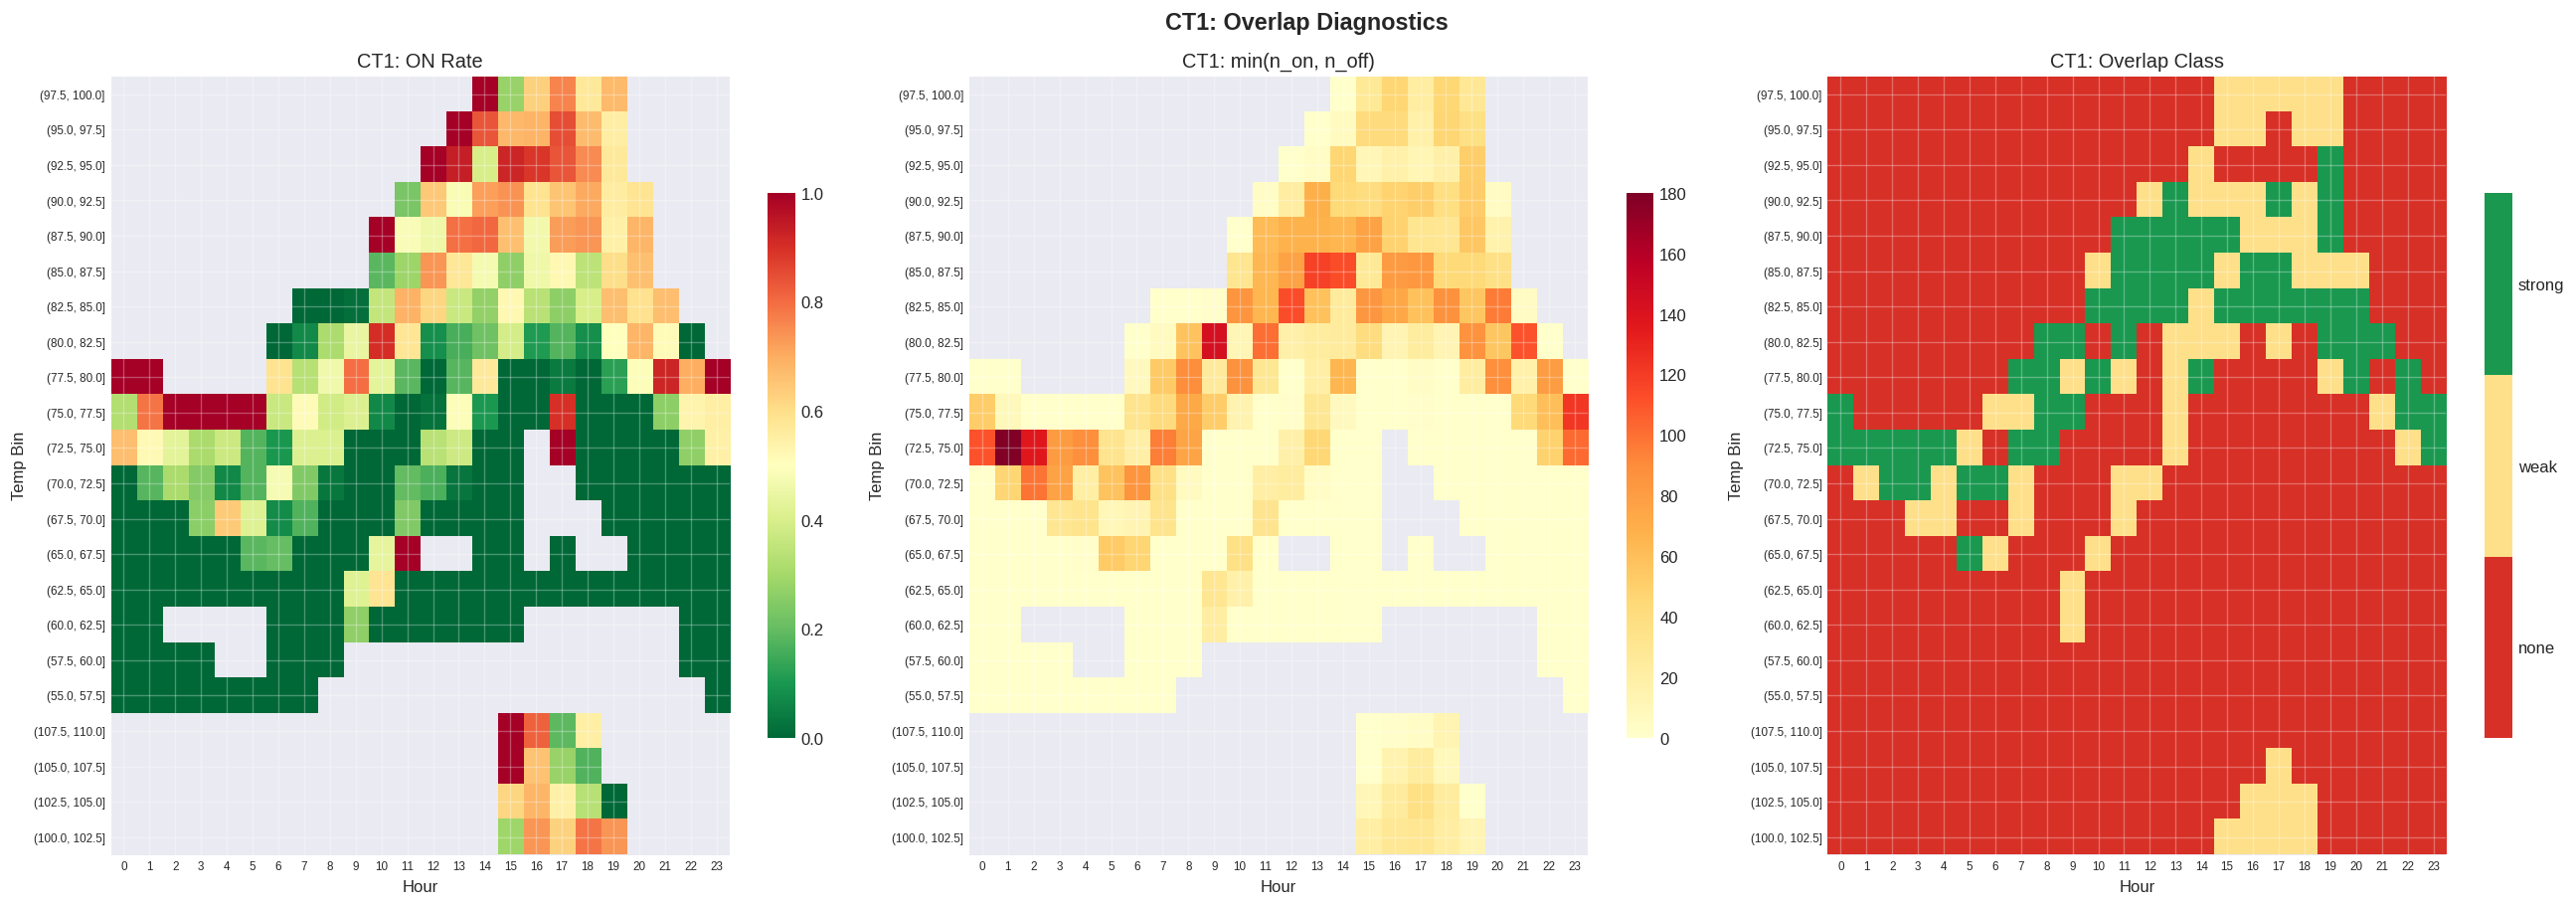

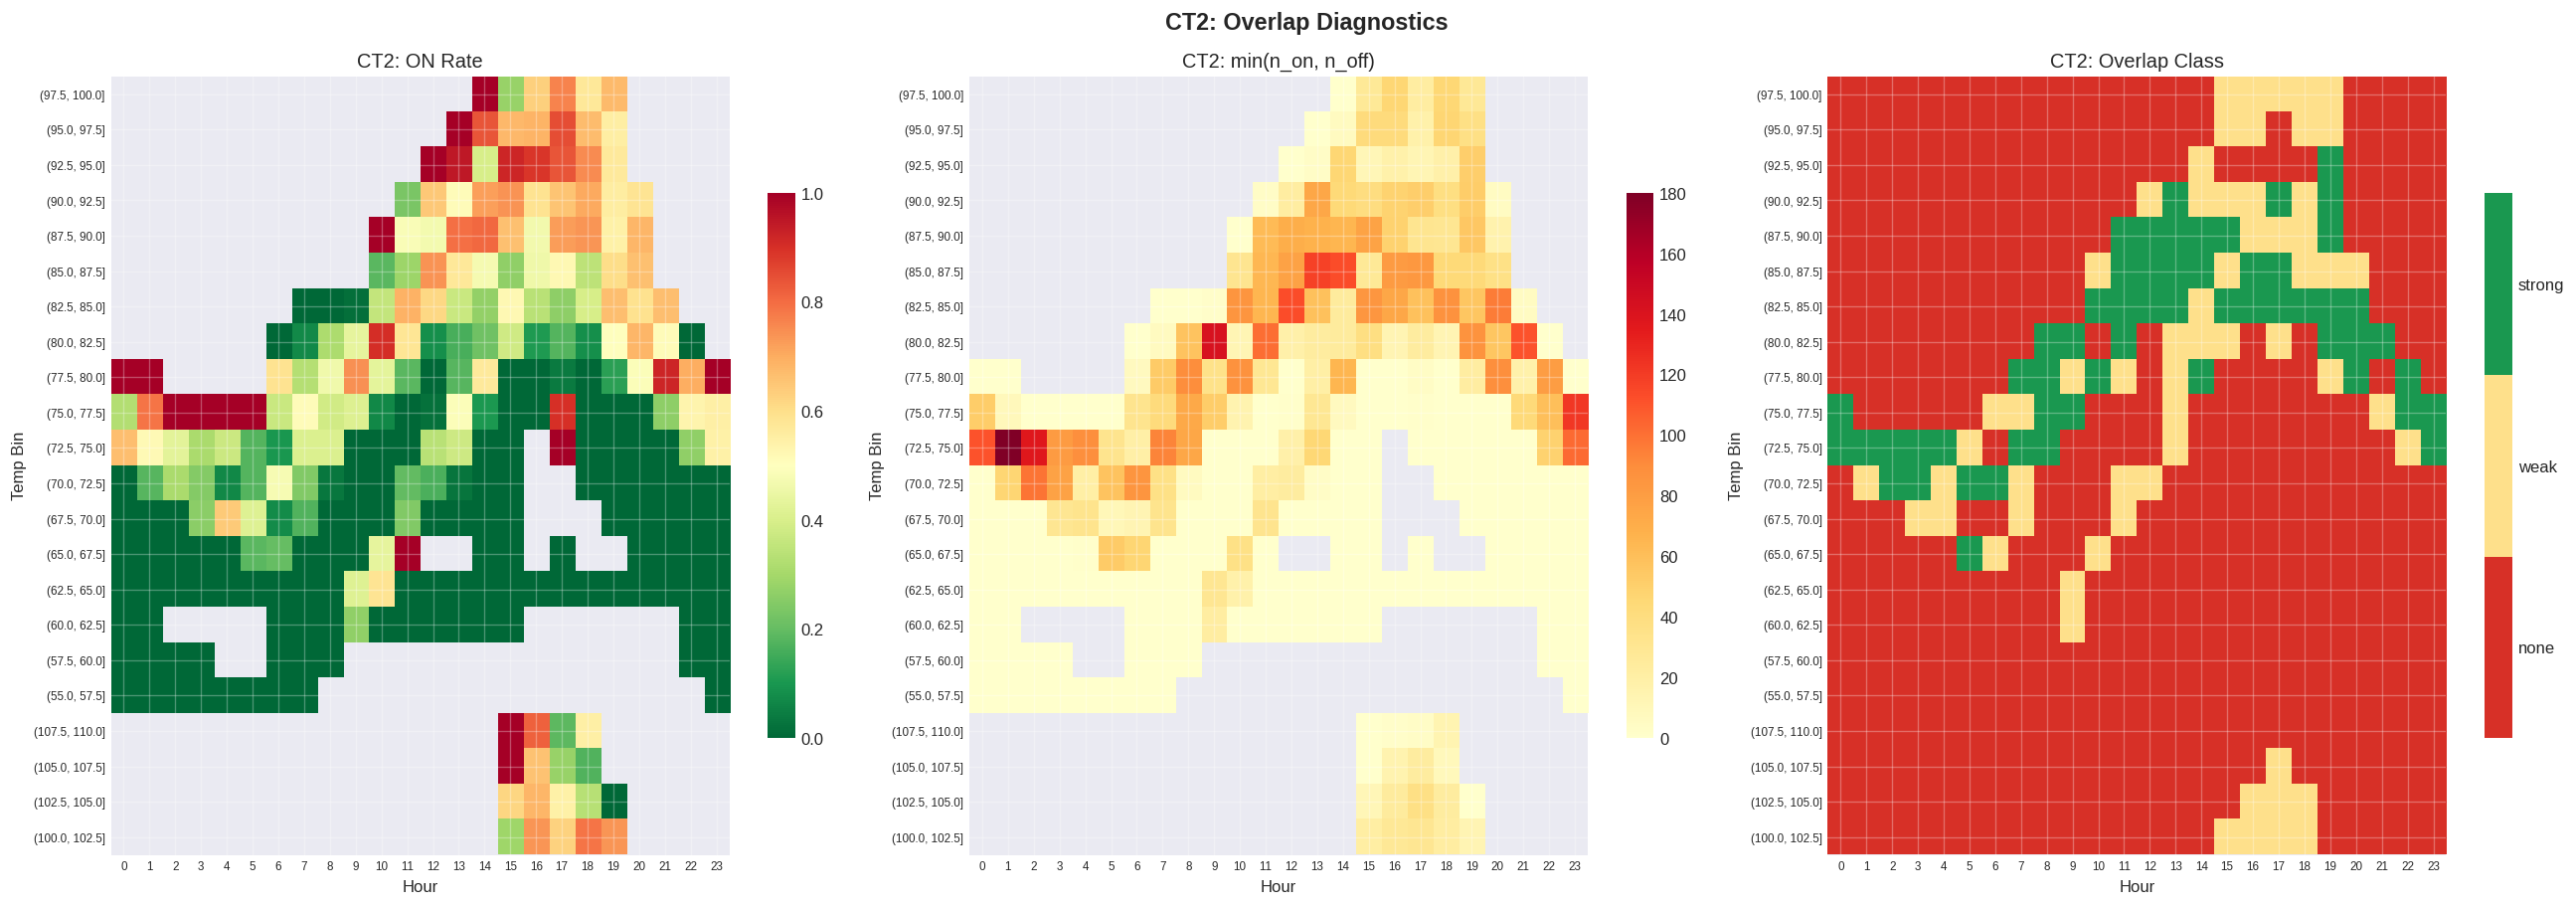


EFFECTS SUMMARY:
turbine spec overlap  ATE_MW  ci_lo  ci_hi  uplift_85F  uplift_90F  uplift_95F     R2  N_train  N_report_base  N_report_strong  strong_frac
    CT1    A  strong  1.1297 1.0084 1.2137      1.2385      1.3853      1.5175 0.9638    33108          33108            12248       0.3699
    CT2    A  strong  1.3231 1.2397 1.4629      1.5249      1.7230      1.8847 0.9400    33133          33133            12258       0.3700

Saved -> ./outputs/effects_summary_specA_overlapON.csv


In [14]:
# ============================================================================
# SAVE MAIN OUTPUTS
# ============================================================================

effects_rows = []

for ct_label, res in all_results.items():
    ct_p = res['ct_prefix']

    # --- Effects summary ---
    effects_rows.append({
        'turbine': ct_label, 'spec': SPEC,
        'overlap': 'strong' if OVL_ON else 'off',
        'ATE_MW': res['ate'],
        'ci_lo': res['ci_lo'], 'ci_hi': res['ci_hi'],
        'uplift_85F': res['u85'], 'uplift_90F': res['u90'], 'uplift_95F': res['u95'],
        'R2': res['model'].rsquared,
        'N_train': len(res['df_train']),
        'N_report_base': len(res['df_report_base']),
        'N_report_strong': len(res['df_report_strong']),
        'strong_frac': (res['ovl_meta']['strong_frac']
                        if res['ovl_meta'] else 1.0),
    })

    # --- Overlap grid CSV ---
    if res['ovl_meta']:
        m = res['ovl_meta']
        m['grid'].to_csv(f'{OUT}/overlap_grid_{ct_label}_{tag}.csv', index=False)
        m['summary'].to_csv(f'{OUT}/overlap_summary_{ct_label}_{tag}.csv', index=False)
        plot_overlap_heatmaps(m['grid'], ct_label, OUT)

    # --- Bootstrap ATE CSV ---
    pd.DataFrame({'boot_ate_mw': res['boot_arr']}).to_csv(
        f'{OUT}/bootstrap_ate_{ct_label}_{tag}.csv', index=False)

    # --- Bootstrap curve CSV ---
    if res['curve']:
        temps, pe, clo, chi = res['curve']
        pd.DataFrame({
            'temp_f': temps, 'uplift_mw': pe, 'ci_lo': clo, 'ci_hi': chi,
        }).to_csv(f'{OUT}/bootstrap_curve_{ct_label}_{tag}.csv', index=False)

# --- Effects table ---
effects_df = pd.DataFrame(effects_rows)
effects_df.to_csv(f'{OUT}/effects_summary_{tag}.csv', index=False)
print('\nEFFECTS SUMMARY:')
print(effects_df.to_string(index=False))
print(f'\nSaved -> {OUT}/effects_summary_{tag}.csv')


### 5c. Main Plots


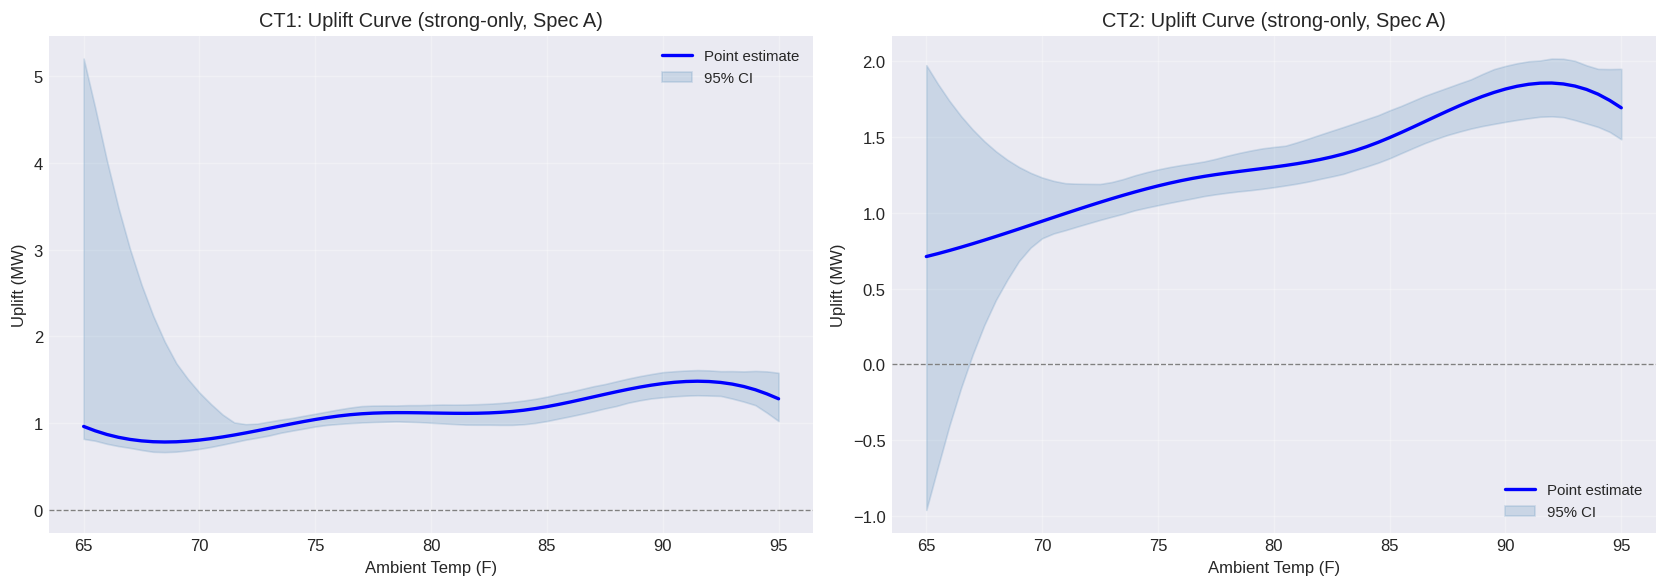

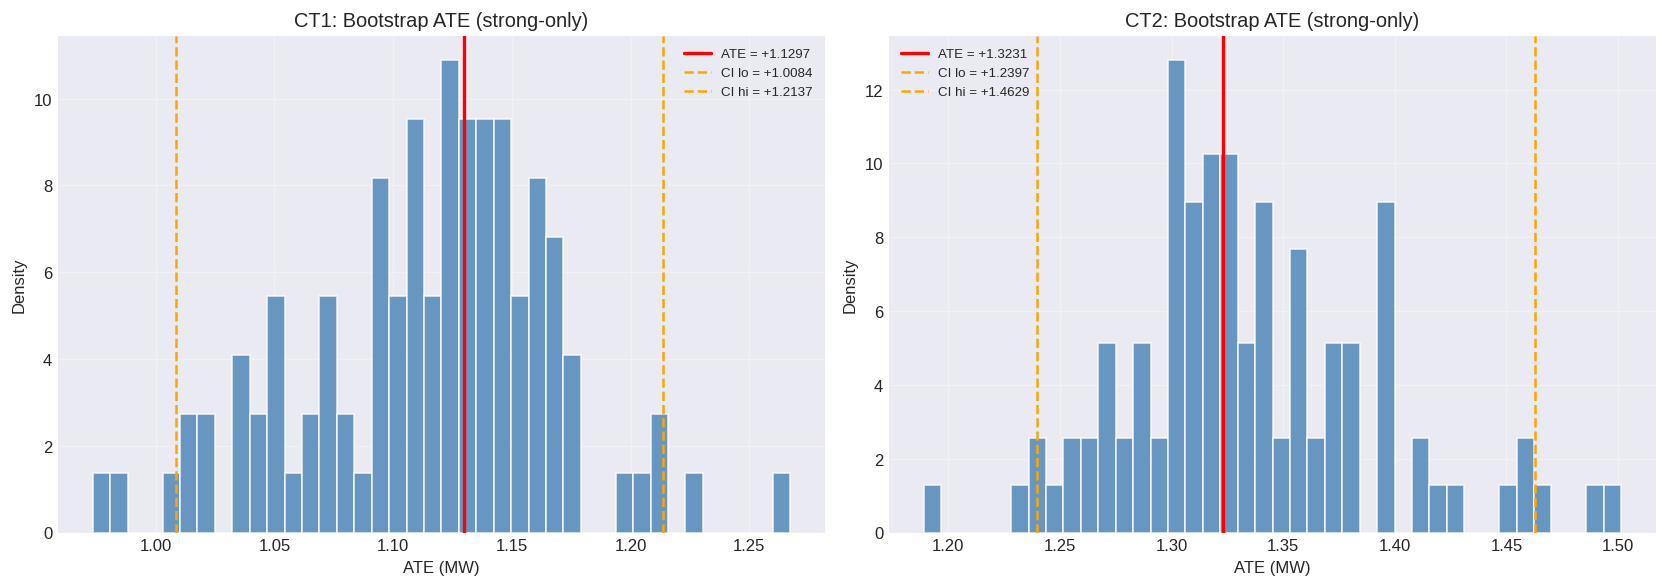

In [15]:
# ============================================================================
# UPLIFT CURVE + BOOTSTRAP CI + BOOTSTRAP ATE DISTRIBUTION
# ============================================================================
n_ct = len(all_results)
if n_ct == 0:
    print('No models fitted')
else:
    # --- Uplift curve ---
    fig, axes = plt.subplots(1, n_ct, figsize=(7*n_ct, 5), squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]
        if res['curve']:
            temps, pe, clo, chi = res['curve']
            ax.plot(temps, pe, 'b-', lw=2, label='Point estimate')
            ax.fill_between(temps, clo, chi, alpha=0.2, color='steelblue',
                            label=f'{int(CONFIG["bootstrap"]["ci_level"]*100)}% CI')
        ax.axhline(0, color='grey', ls='--', lw=0.8)
        ax.set_xlabel('Ambient Temp (F)')
        ax.set_ylabel('Uplift (MW)')
        lbl = 'strong-only' if OVL_ON else 'full'
        ax.set_title(f'{ct_l}: Uplift Curve ({lbl}, Spec {SPEC})')
        ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(f'{OUT}/uplift_curve_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Bootstrap ATE distribution ---
    fig, axes = plt.subplots(1, n_ct, figsize=(7*n_ct, 5), squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]
        valid = res['boot_arr'][~np.isnan(res['boot_arr'])]
        ax.hist(valid, bins=40, color='steelblue', edgecolor='white',
                alpha=0.8, density=True)
        ax.axvline(res['ate'], color='red', lw=2,
                   label=f'ATE = {res["ate"]:+.4f}')
        ax.axvline(res['ci_lo'], color='orange', lw=1.5, ls='--',
                   label=f'CI lo = {res["ci_lo"]:+.4f}')
        ax.axvline(res['ci_hi'], color='orange', lw=1.5, ls='--',
                   label=f'CI hi = {res["ci_hi"]:+.4f}')
        ax.set_xlabel('ATE (MW)'); ax.set_ylabel('Density')
        lbl = 'strong-only' if OVL_ON else 'full'
        ax.set_title(f'{ct_l}: Bootstrap ATE ({lbl})')
        ax.legend(fontsize=8)
    plt.tight_layout()
    fig.savefig(f'{OUT}/bootstrap_ate_dist_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [16]:
# ============================================================================
# FILES INVENTORY
# ============================================================================
print('\nFILES SAVED:')
for f in sorted(os.listdir(OUT)):
    sz = os.path.getsize(os.path.join(OUT, f)) / 1024
    print(f'  {f:55s} {sz:7.1f} KB')



FILES SAVED:
  bootstrap_ate_CT1_specA_overlapON.csv                       1.8 KB
  bootstrap_ate_CT2_specA_overlapON.csv                       1.8 KB
  bootstrap_ate_dist_specA_overlapON.png                     51.3 KB
  bootstrap_curve_CT1_specA_overlapON.csv                     3.7 KB
  bootstrap_curve_CT2_specA_overlapON.csv                     3.7 KB
  effects_summary_specA_overlapON.csv                         0.5 KB
  overlap_grid_CT1_specA_overlapON.csv                       22.8 KB
  overlap_grid_CT2_specA_overlapON.csv                       22.8 KB
  overlap_heatmap_CT1.png                                   129.8 KB
  overlap_heatmap_CT2.png                                   130.3 KB
  overlap_summary_CT1_specA_overlapON.csv                     0.7 KB
  overlap_summary_CT2_specA_overlapON.csv                     0.7 KB
  uplift_curve_specA_overlapON.png                           99.9 KB


---
## 6. Optional Diagnostics
Controlled by `CONFIG['diagnostics']['enabled']`. Turning this off does not affect main outputs.


In [17]:
# ============================================================================
# DIAGNOSTICS GATE
# ============================================================================
DIAG = CONFIG['diagnostics']['enabled']
if not DIAG:
    print('Diagnostics disabled in CONFIG')


### 6a. Overlap Statistics & Temperature Distribution


CT1: ON=10,441  OFF=22,667  rate=31.5%
CT2: ON=10,456  OFF=22,677  rate=31.6%


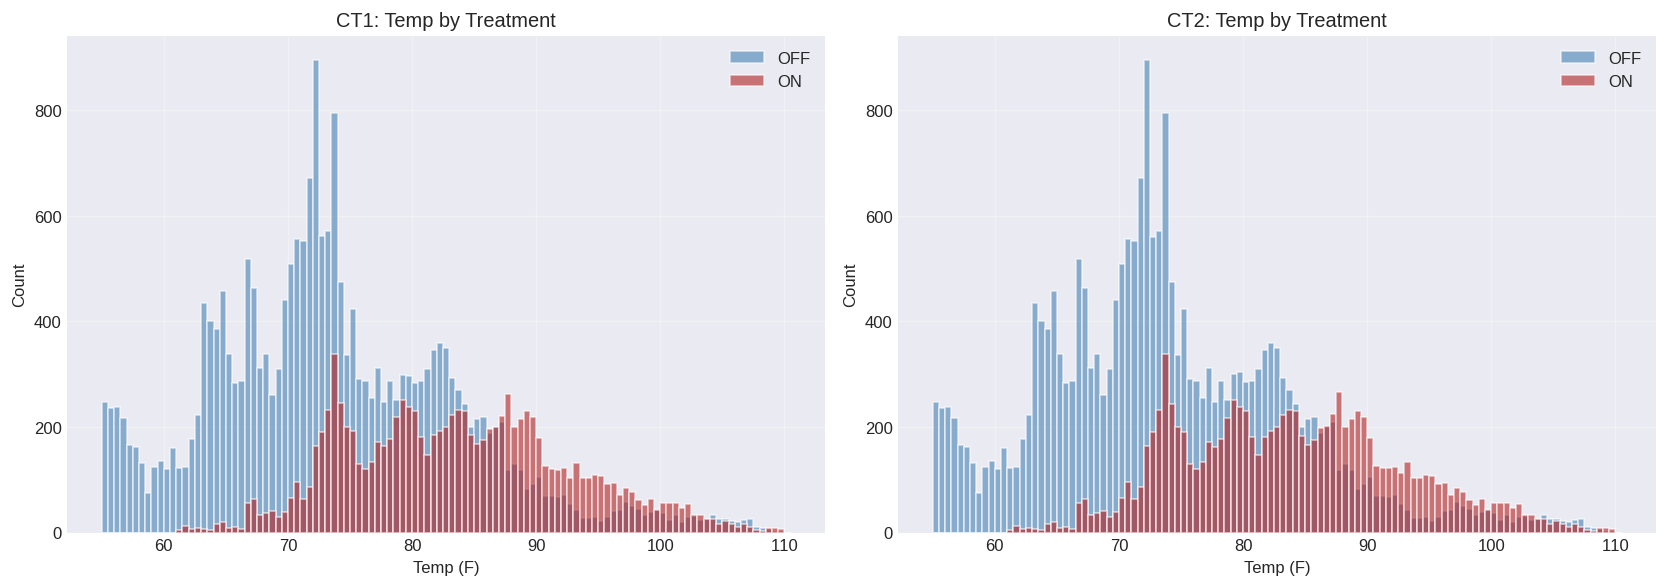

In [18]:
if DIAG:
    for ct_l, res in all_results.items():
        df_rb = res['df_report_base']
        n_on  = int((df_rb['D'] == 1).sum())
        n_off = int((df_rb['D'] == 0).sum())
        print(f'{ct_l}: ON={n_on:,}  OFF={n_off:,}  '
              f'rate={n_on/(n_on+n_off):.1%}')

    fig, axes = plt.subplots(1, len(all_results), figsize=(7*len(all_results), 5),
                             squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]; df_rb = res['df_report_base']
        lo, hi = CONFIG['data']['report_temp_range_F']
        bins = np.arange(lo, hi + 1, 0.5)
        ax.hist(df_rb.loc[df_rb['D']==0, 'ambient_air_temp_f'],
                bins=bins, alpha=0.6, label='OFF', color='steelblue', edgecolor='white')
        ax.hist(df_rb.loc[df_rb['D']==1, 'ambient_air_temp_f'],
                bins=bins, alpha=0.6, label='ON', color='firebrick', edgecolor='white')
        ax.set_xlabel('Temp (F)'); ax.set_ylabel('Count')
        ax.set_title(f'{ct_l}: Temp by Treatment'); ax.legend()
    plt.tight_layout(); plt.show()


### 6b. Hour-of-Day Distribution


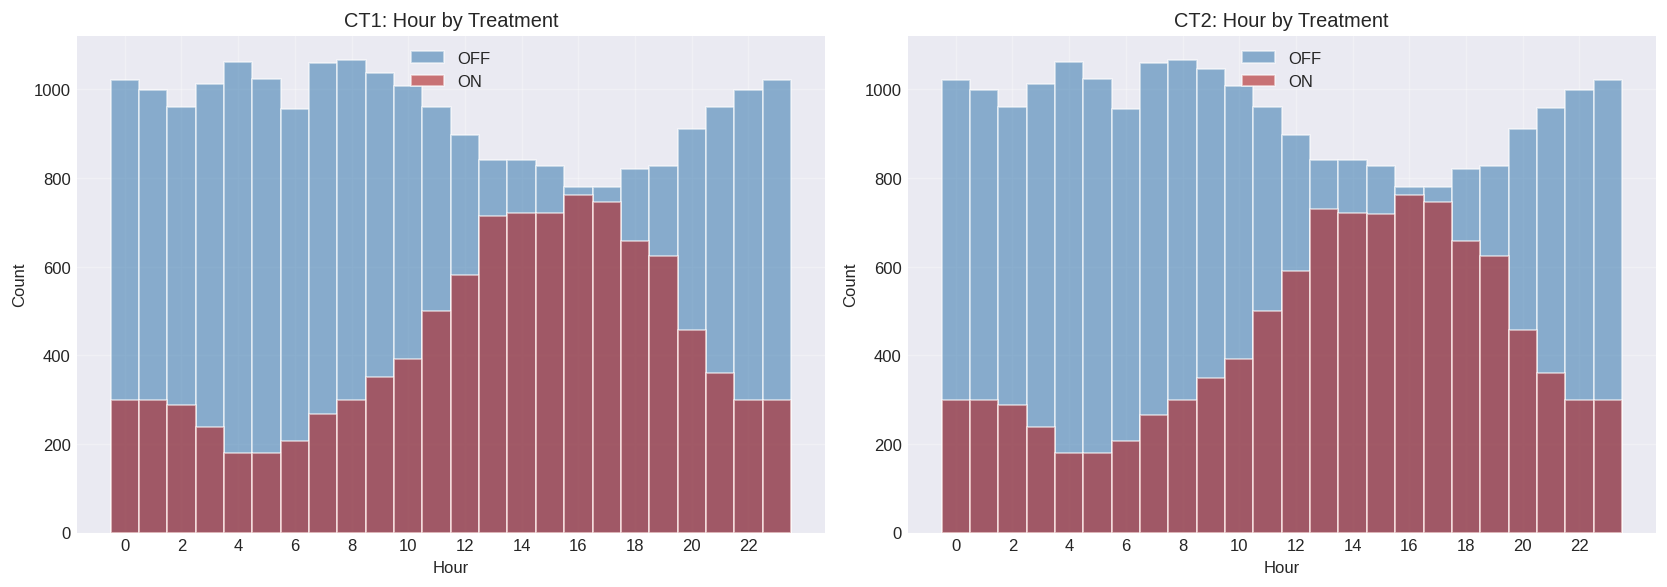

In [19]:
if DIAG:
    fig, axes = plt.subplots(1, len(all_results), figsize=(7*len(all_results), 5),
                             squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]; df_rb = res['df_report_base']
        bins = np.arange(-0.5, 24.5, 1)
        ax.hist(df_rb.loc[df_rb['D']==0, 'hour'], bins=bins,
                alpha=0.6, label='OFF', color='steelblue', edgecolor='white')
        ax.hist(df_rb.loc[df_rb['D']==1, 'hour'], bins=bins,
                alpha=0.6, label='ON', color='firebrick', edgecolor='white')
        ax.set_xlabel('Hour'); ax.set_ylabel('Count')
        ax.set_title(f'{ct_l}: Hour by Treatment'); ax.legend()
        ax.set_xticks(range(0, 24, 2))
    plt.tight_layout(); plt.show()


### 6c. Binned Difference (raw means, no model)


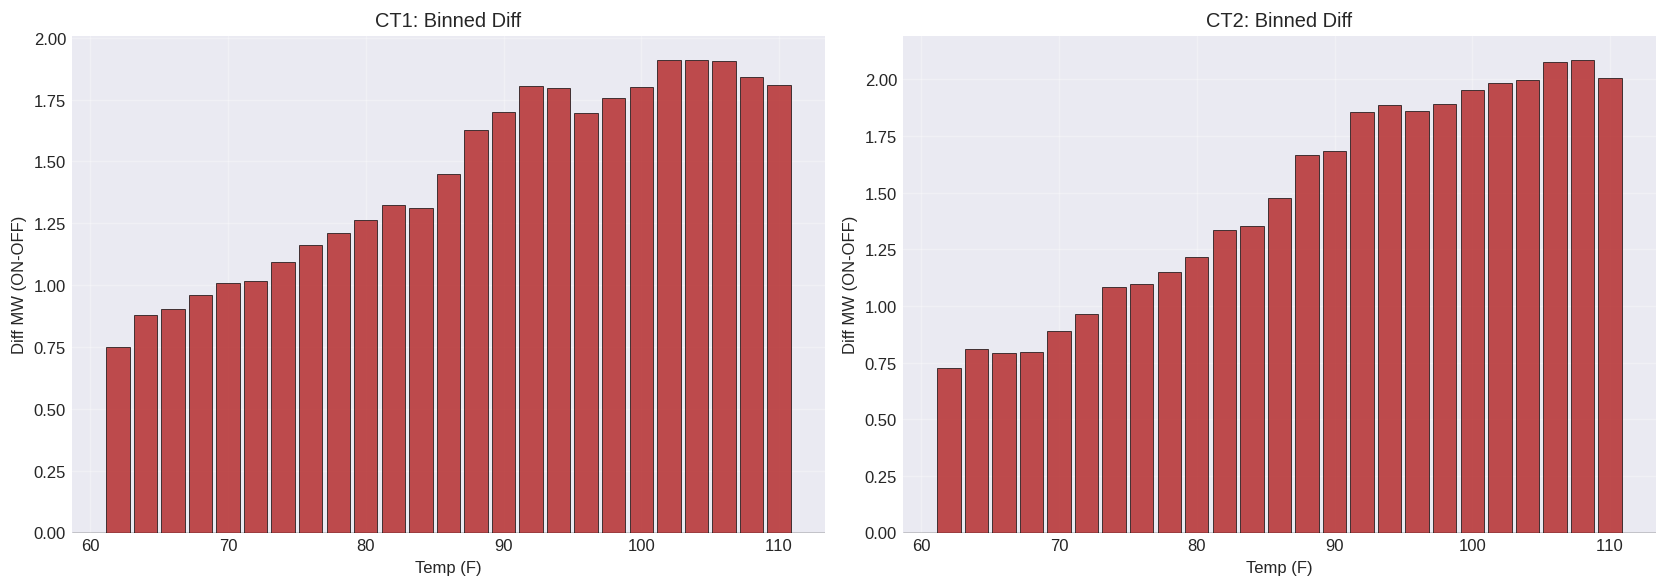

In [20]:
if DIAG:
    bw = CONFIG['diagnostics']['binned_diff_width_F']
    fig, axes = plt.subplots(1, len(all_results), figsize=(7*len(all_results), 5),
                             squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]; df_rb = res['df_report_base']
        ct_p = res['ct_prefix']
        lo, hi = CONFIG['data']['report_temp_range_F']
        bins_arr = np.arange(lo, hi + bw, bw)
        recs = []
        for j in range(len(bins_arr) - 1):
            mask = df_rb['ambient_air_temp_f'].between(bins_arr[j], bins_arr[j+1], inclusive='left')
            on_  = df_rb.loc[mask & (df_rb['D']==1), f'{ct_p}_power_mw']
            off_ = df_rb.loc[mask & (df_rb['D']==0), f'{ct_p}_power_mw']
            recs.append({'mid': (bins_arr[j]+bins_arr[j+1])/2,
                         'diff': on_.mean()-off_.mean() if len(on_)>0 and len(off_)>0 else np.nan,
                         'n_on': len(on_), 'n_off': len(off_)})
        bd = pd.DataFrame(recs).dropna()
        colors = ['firebrick' if d>0 else 'steelblue' for d in bd['diff']]
        ax.bar(bd['mid'], bd['diff'], width=bw*0.85, color=colors,
               edgecolor='black', lw=0.5, alpha=0.8)
        ax.axhline(0, color='black', lw=0.8)
        ax.set_xlabel('Temp (F)'); ax.set_ylabel('Diff MW (ON-OFF)')
        ax.set_title(f'{ct_l}: Binned Diff')
    plt.tight_layout()
    bd_all = pd.DataFrame(recs) # last turbine's for save
    plt.show()


### 6d. Day-Block Train/Test Performance


CT1: test RMSE=0.1152  R2=0.9588  (27,476 train / 5,632 test)


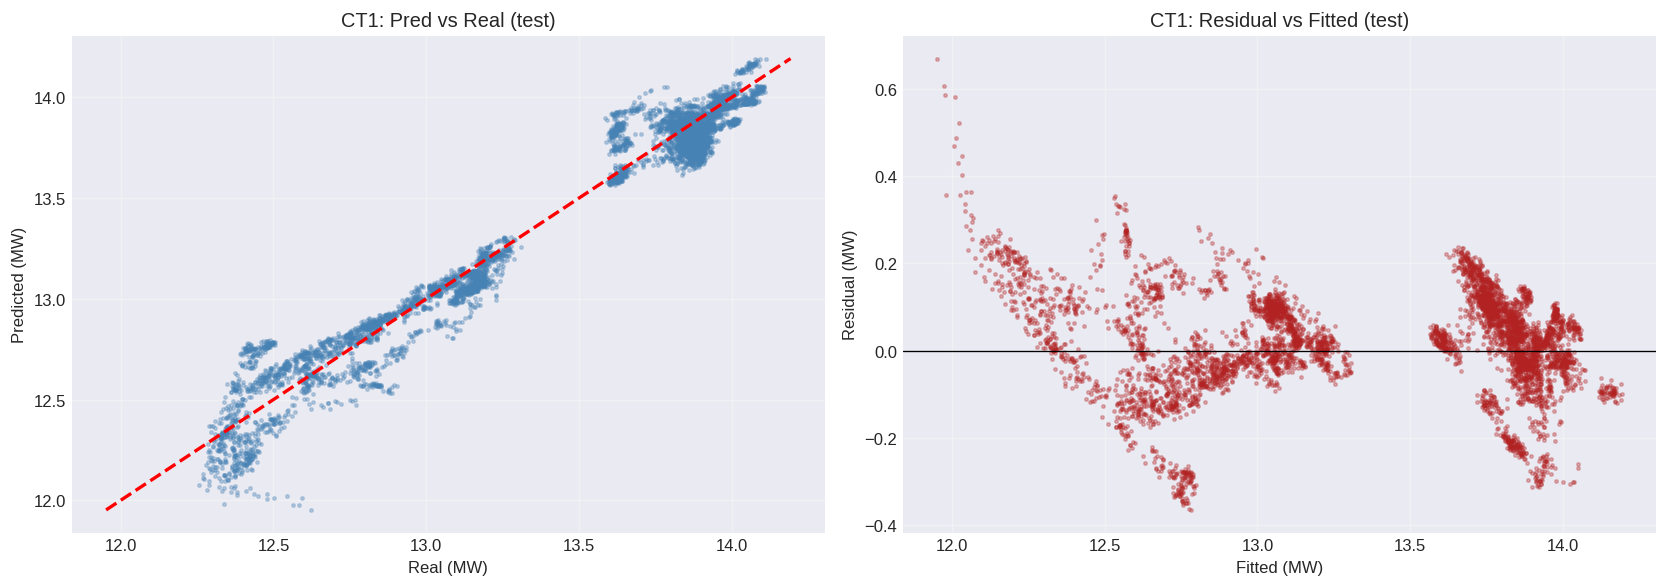

CT2: test RMSE=0.1365  R2=0.9663  (27,059 train / 6,074 test)


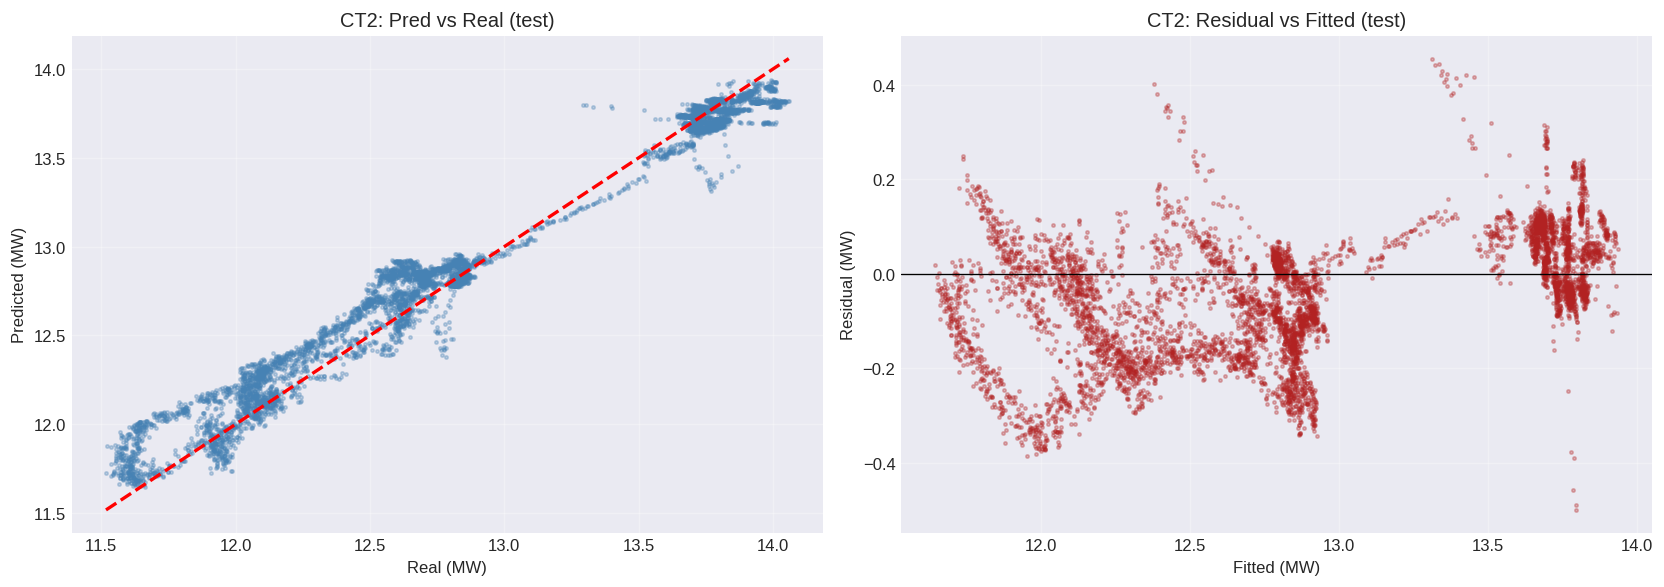

In [21]:
if DIAG:
    np.random.seed(CONFIG['seed'])
    test_frac = CONFIG['diagnostics']['test_days_frac']

    for ct_l, res in all_results.items():
        m = res['model']; df_reg = m._df_reg.copy()
        ct_p = m._ct_prefix
        y_col, formula = build_formula(ct_p, SPEC)

        unique_days = np.array(sorted(df_reg['day'].unique()))
        n_test = max(1, int(len(unique_days) * test_frac))
        test_days = np.random.choice(unique_days, size=n_test, replace=False)

        df_tr = df_reg[~df_reg['day'].isin(test_days)]
        df_te = df_reg[df_reg['day'].isin(test_days)].copy()

        if len(df_te) < 30:
            print(f'{ct_l}: too few test rows'); continue

        m_tr = smf.ols(formula, data=df_tr).fit()
        t_lo = df_tr['ambient_air_temp_f'].min()
        t_hi = df_tr['ambient_air_temp_f'].max()
        df_te['ambient_air_temp_f'] = np.clip(
            df_te['ambient_air_temp_f'], t_lo, t_hi)
        yhat = m_tr.predict(df_te)
        y_te = df_te[y_col]

        rmse = np.sqrt(mean_squared_error(y_te, yhat))
        r2   = r2_score(y_te, yhat)
        print(f'{ct_l}: test RMSE={rmse:.4f}  R2={r2:.4f}  '
              f'({len(df_tr):,} train / {len(df_te):,} test)')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].scatter(y_te, yhat, s=4, alpha=0.3, color='steelblue')
        lims = [min(y_te.min(), yhat.min()), max(y_te.max(), yhat.max())]
        axes[0].plot(lims, lims, 'r--', lw=2)
        axes[0].set_xlabel('Real (MW)'); axes[0].set_ylabel('Predicted (MW)')
        axes[0].set_title(f'{ct_l}: Pred vs Real (test)')

        resid = y_te.values - yhat.values
        axes[1].scatter(yhat, resid, s=4, alpha=0.3, color='firebrick')
        axes[1].axhline(0, color='black', lw=0.8)
        axes[1].set_xlabel('Fitted (MW)'); axes[1].set_ylabel('Residual (MW)')
        axes[1].set_title(f'{ct_l}: Residual vs Fitted (test)')
        plt.tight_layout(); plt.show()


### 6e. Day-Level Jackknife ATE


CT1 JK: mean=+1.0122  std=0.0421  range=[+0.9858, +1.2232]
CT2 JK: mean=+1.1598  std=0.0175  range=[+1.1208, +1.2082]


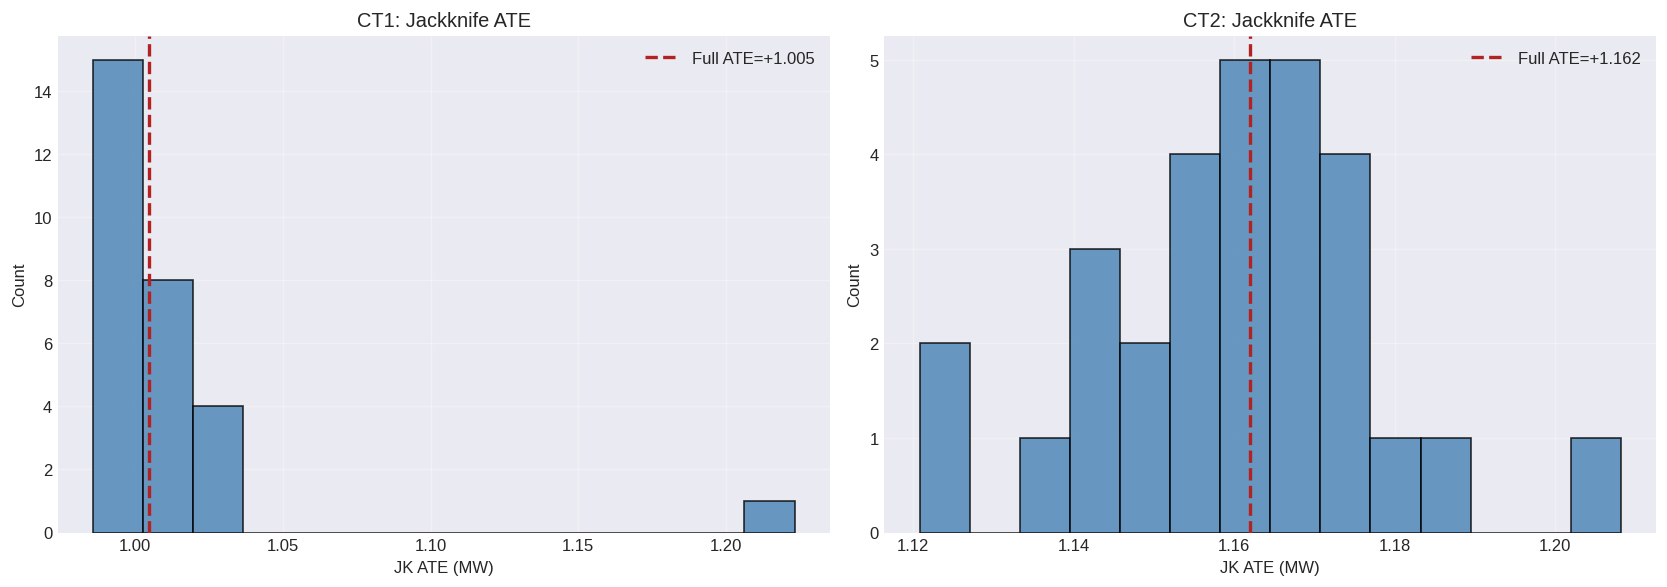

In [22]:
if DIAG and CONFIG['diagnostics']['jackknife_enabled']:
    jk_max = CONFIG['diagnostics']['jackknife_max_days']

    fig, axes = plt.subplots(1, len(all_results),
                             figsize=(7*len(all_results), 5), squeeze=False)
    for i, (ct_l, res) in enumerate(all_results.items()):
        ax = axes[0, i]; m = res['model']
        df_reg = m._df_reg.copy()
        ct_p = m._ct_prefix
        y_col, formula = build_formula(ct_p, SPEC)

        full_ate = counterfactual_uplift(m).mean()
        days = df_reg['day'].unique()
        if len(days) > jk_max:
            np.random.seed(CONFIG['seed'])
            days = np.random.choice(days, size=jk_max, replace=False)

        jk_ates = []
        for d in days:
            df_jk = df_reg[df_reg['day'] != d]
            if len(df_jk) < 100: continue
            try:
                m_jk = smf.ols(formula, data=df_jk).fit()
                m_jk._df_reg = df_jk; m_jk._ct_prefix = ct_p
                jk_ates.append(counterfactual_uplift(m_jk).mean())
            except Exception:
                pass

        jk = np.array(jk_ates)
        print(f'{ct_l} JK: mean={jk.mean():+.4f}  std={jk.std():.4f}  '
              f'range=[{jk.min():+.4f}, {jk.max():+.4f}]')

        ax.hist(jk, bins=min(20, max(5, len(jk)//2)),
                color='steelblue', edgecolor='black', lw=0.5, alpha=0.8)
        ax.axvline(full_ate, color='firebrick', lw=2, ls='--',
                   label=f'Full ATE={full_ate:+.3f}')
        ax.set_xlabel('JK ATE (MW)'); ax.set_ylabel('Count')
        ax.set_title(f'{ct_l}: Jackknife ATE'); ax.legend()
    plt.tight_layout(); plt.show()
